In [58]:
import os
import json
import time
import shutil
import re
from pathlib import Path
from collections import Counter

import pandas as pd

from dotenv import load_dotenv

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

In [59]:
PROJECT_ROOT = Path(r"C:\Users\asguug\Documents\rag-agent")

if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DOCS_DIR = PROJECT_ROOT / "data" / "docs"
EVAL_DIR = PROJECT_ROOT / "data" / "eval"
CHROMA_WEEK5_DIR = PROJECT_ROOT / "data" / "chroma_week5"

EVAL_DIR.mkdir(parents=True, exist_ok=True)
CHROMA_WEEK5_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(PROJECT_ROOT / ".env")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DOCS_DIR:", DOCS_DIR)
print("EVAL_DIR:", EVAL_DIR)
print("CHROMA_WEEK5_DIR:", CHROMA_WEEK5_DIR)
print("OPENAI_API_KEY exists:", bool(os.getenv("OPENAI_API_KEY")))

PROJECT_ROOT: C:\Users\asguug\Documents\rag-agent
DOCS_DIR: C:\Users\asguug\Documents\rag-agent\data\docs
EVAL_DIR: C:\Users\asguug\Documents\rag-agent\data\eval
CHROMA_WEEK5_DIR: C:\Users\asguug\Documents\rag-agent\data\chroma_week5
OPENAI_API_KEY exists: True


In [60]:
md_files = sorted(DOCS_DIR.glob("*.md"))

print("Markdown 문서 수:", len(md_files))

for path in md_files:
    print("-", path.name)

assert md_files, f"Markdown 문서가 없습니다. 경로 확인 필요: {DOCS_DIR}"


raw_docs = []

for path in md_files:
    raw_docs.append(
        Document(
            page_content=path.read_text(encoding="utf-8"),
            metadata={
                "source": str(path),
                "source_file": path.name,
                "game_key": path.stem,
                "document_type": "game_profile",
                "source_type": "steam",
            },
        )
    )

print("로드된 문서 수:", len(raw_docs))

Markdown 문서 수: 5
- baldurs_gate_3.md
- cyberpunk_2077.md
- hollow_knight.md
- monster_hunter_world.md
- no_mans_sky.md
로드된 문서 수: 5


In [61]:
def split_markdown_by_fixed_sections(doc: Document) -> list[Document]:
    """
    Steam 게임 Markdown 문서를 고정 section 단위로 분리한다.

    사용 section:
    - metadata
    - store_summary
    - about
    - review
    - news
    """
    source = doc.metadata.get("source", "")
    source_file = doc.metadata.get("source_file", Path(source).name)
    game_key = doc.metadata.get("game_key", Path(source_file).stem)

    text = doc.page_content

    section_patterns = [
        ("metadata", "## Metadata"),
        ("store_summary", "## Store Summary"),
        ("about", "## About The Game"),
        ("review", "## Recent Steam Reviews"),
        ("news", "## Steam News and Updates"),
    ]

    section_docs = []

    for idx, (section_name, heading) in enumerate(section_patterns):
        start = text.find(heading)

        if start == -1:
            continue

        if idx + 1 < len(section_patterns):
            next_heading = section_patterns[idx + 1][1]
            end = text.find(next_heading, start + len(heading))

            if end == -1:
                end = len(text)
        else:
            end = len(text)

        section_text = text[start:end].strip()

        if not section_text:
            continue

        section_docs.append(
            Document(
                page_content=section_text,
                metadata={
                    **doc.metadata,
                    "source": source,
                    "source_file": source_file,
                    "game_key": game_key,
                    "section": section_name,
                    "document_type": "game_profile",
                    "source_type": "steam",
                },
            )
        )

    return section_docs


section_docs = []

for doc in raw_docs:
    section_docs.extend(split_markdown_by_fixed_sections(doc))

print("원본 Markdown 문서 수:", len(raw_docs))
print("섹션 문서 수:", len(section_docs))

section_counter = Counter(doc.metadata.get("section", "unknown") for doc in section_docs)
print(section_counter)

for doc in section_docs[:5]:
    print(doc.metadata["source_file"], doc.metadata["section"], len(doc.page_content))

원본 Markdown 문서 수: 5
섹션 문서 수: 25
Counter({'metadata': 5, 'store_summary': 5, 'about': 5, 'review': 5, 'news': 5})
baldurs_gate_3.md metadata 636
baldurs_gate_3.md store_summary 224
baldurs_gate_3.md about 5376
baldurs_gate_3.md review 5101
baldurs_gate_3.md news 2704


In [62]:
def normalize_section_name(section_title: str) -> str:
    section_title = str(section_title).strip().lower()

    if section_title in ["metadata", "store_summary", "about", "review", "news"]:
        return section_title

    if "metadata" in section_title:
        return "metadata"

    if "store summary" in section_title:
        return "store_summary"

    if "about" in section_title:
        return "about"

    if "review" in section_title:
        return "review"

    if "news" in section_title or "update" in section_title:
        return "news"

    return "unknown"


def add_chunk_metadata(
    chunks: list[Document],
    strategy_name: str,
    chunk_size,
    chunk_overlap,
) -> list[Document]:
    """
    chunk별 공통 metadata를 보강한다.
    """
    enriched = []

    for idx, chunk in enumerate(chunks):
        metadata = dict(chunk.metadata)

        metadata["chunk_strategy"] = strategy_name
        metadata["chunk_index"] = idx
        metadata["chunk_size_setting"] = str(chunk_size)
        metadata["chunk_overlap_setting"] = str(chunk_overlap)
        metadata["char_count"] = len(chunk.page_content)

        if "source_file" not in metadata:
            metadata["source_file"] = Path(metadata.get("source", "")).name

        if "game_key" not in metadata:
            metadata["game_key"] = Path(metadata.get("source_file", "")).stem

        metadata["section"] = normalize_section_name(metadata.get("section", "unknown"))

        if "document_type" not in metadata:
            metadata["document_type"] = "game_profile"

        if "source_type" not in metadata:
            metadata["source_type"] = "steam"

        enriched.append(
            Document(
                page_content=chunk.page_content,
                metadata=metadata,
            )
        )

    return enriched

In [63]:
WEEK5_BASELINE_STRATEGY = "B_recursive_large_1000_200"


def make_chunks_strategy_b(section_docs: list[Document]) -> list[Document]:
    """
    4주차 최종 선택 전략 B:
    section 분리 후 RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        length_function=len,
        separators=["\n\n", "\n", " ", ""],
    )

    chunks = splitter.split_documents(section_docs)

    return add_chunk_metadata(
        chunks=chunks,
        strategy_name=WEEK5_BASELINE_STRATEGY,
        chunk_size=1000,
        chunk_overlap=200,
    )


chunks_b = make_chunks_strategy_b(section_docs)

print("전략 B chunk 수:", len(chunks_b))
print("첫 번째 chunk metadata:")
print(chunks_b[0].metadata)
print("\n첫 번째 chunk preview:")
print(chunks_b[0].page_content[:500])

전략 B chunk 수: 95
첫 번째 chunk metadata:
{'source': 'C:\\Users\\asguug\\Documents\\rag-agent\\data\\docs\\baldurs_gate_3.md', 'source_file': 'baldurs_gate_3.md', 'game_key': 'baldurs_gate_3', 'document_type': 'game_profile', 'source_type': 'steam', 'section': 'metadata', 'chunk_strategy': 'B_recursive_large_1000_200', 'chunk_index': 0, 'chunk_size_setting': '1000', 'chunk_overlap_setting': '200', 'char_count': 636}

첫 번째 chunk preview:
## Metadata
- game_key: baldurs_gate_3
- appid: 1086940
- title: Baldur's Gate 3
- release_date: Aug 3, 2023
- developers: Larian Studios
- publishers: Larian Studios
- genres: Adventure, RPG, Strategy
- categories: Single-player, Multi-player, Co-op, Online Co-op, LAN Co-op, Cross-Platform Multiplayer, Steam Achievements, Full controller support, Steam Trading Cards, Adjustable Text Size, Camera Comfort, Color Alternatives, Custom Volume Controls, Adjustable Difficulty, Playable without Timed I


In [64]:
chunk_stat_records = []

lengths = [len(chunk.page_content) for chunk in chunks_b]
section_counter = Counter(chunk.metadata.get("section", "unknown") for chunk in chunks_b)
game_counter = Counter(chunk.metadata.get("game_key", "unknown") for chunk in chunks_b)

chunk_stat_records.append(
    {
        "strategy": WEEK5_BASELINE_STRATEGY,
        "chunk_count": len(chunks_b),
        "min_chars": min(lengths),
        "max_chars": max(lengths),
        "avg_chars": round(sum(lengths) / len(lengths), 1),
        "section_distribution": json.dumps(dict(section_counter), ensure_ascii=False),
        "game_distribution": json.dumps(dict(game_counter), ensure_ascii=False),
    }
)

chunk_stats_df = pd.DataFrame(chunk_stat_records)

In [65]:
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

print("Embedding model loaded:", EMBEDDING_MODEL_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model loaded: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [66]:
DENSE_BASELINE_COLLECTION = "week5_dense_baseline_b_1000_200"
DENSE_BASELINE_DIR = CHROMA_WEEK5_DIR / DENSE_BASELINE_COLLECTION

if DENSE_BASELINE_DIR.exists():
    shutil.rmtree(DENSE_BASELINE_DIR)

DENSE_BASELINE_DIR.mkdir(parents=True, exist_ok=True)

dense_vectorstore = Chroma.from_documents(
    documents=chunks_b,
    embedding=embeddings,
    collection_name=DENSE_BASELINE_COLLECTION,
    persist_directory=str(DENSE_BASELINE_DIR),
)

print("Dense baseline vectorstore created")
print("persist_directory:", DENSE_BASELINE_DIR)
print("chunk_count:", len(chunks_b))

PermissionError: [WinError 32] 다른 프로세스가 파일을 사용 중이기 때문에 프로세스가 액세스 할 수 없습니다: 'C:\\Users\\asguug\\Documents\\rag-agent\\data\\chroma_week5\\week5_dense_baseline_b_1000_200\\9f49532c-aedc-4c1e-a4ba-0425b1784f59\\data_level0.bin'

In [ ]:
def preview_docs(docs, max_chars: int = 250):
    rows = []

    for rank, doc in enumerate(docs, start=1):
        rows.append(
            {
                "rank": rank,
                "source_file": doc.metadata.get("source_file"),
                "game_key": doc.metadata.get("game_key"),
                "section": doc.metadata.get("section"),
                "chunk_index": doc.metadata.get("chunk_index"),
                "preview": doc.page_content[:max_chars].replace("\n", " "),
            }
        )

    return pd.DataFrame(rows)

In [ ]:
eval_questions = [
    "Hollow Knight는 어떤 플레이 스타일의 게임인가요?",
    "Hollow Knight의 분위기나 월드 구성은 어떤 특징이 있나요?",
    "Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?",
    "Monster Hunter: World는 협동 플레이 측면에서 어떤 특징이 있나요?",
    "Baldur's Gate 3는 어떤 RPG인가요?",
    "Baldur's Gate 3에서 선택과 서사는 어떤 역할을 하나요?",
    "No Man's Sky는 업데이트와 관련해서 어떤 내용이 있나요?",
    "No Man's Sky의 최근 뉴스나 업데이트 방향은 무엇인가요?",
    "Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?",
    "Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?",
]

pd.DataFrame({"question": eval_questions})

,question
0,Hollow Knight는 어떤 플레이 스타일의 게임인가요?
1,Hollow Knight의 분위기나 월드 구성은 어떤 특징이 있나요?
2,Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?
3,Monster Hunter: World는 협동 플레이 측면에서 어떤 특징이 있나요?
4,Baldur's Gate 3는 어떤 RPG인가요?
5,Baldur's Gate 3에서 선택과 서사는 어떤 역할을 하나요?
6,No Man's Sky는 업데이트와 관련해서 어떤 내용이 있나요?
7,No Man's Sky의 최근 뉴스나 업데이트 방향은 무엇인가요?
8,Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?
9,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?


In [ ]:
def infer_intent(question: str) -> str:
    """
    질문의 retrieval intent를 rule 기반으로 단순 분류한다.

    반환값:
    - gameplay: 플레이 스타일, 전투, 분위기, 핵심 루프 등
    - review: 리뷰, 평가, 반응, 민심 등
    - news: 업데이트, 패치, 뉴스 등
    - general: 그 외 일반 질문
    """
    q = question.lower()

    review_keywords = [
        "리뷰", "평가", "반응", "민심", "여론",
        "review", "reviews", "sentiment",
    ]

    news_keywords = [
        "업데이트", "패치", "뉴스", "최근 뉴스",
        "update", "updates", "patch", "news",
    ]

    gameplay_keywords = [
        "플레이", "전투", "루프", "스타일", "분위기", "월드",
        "협동", "선택", "서사", "특징", "rpg",
        "gameplay", "combat", "style", "world", "co-op",
    ]

    if any(keyword in q for keyword in review_keywords):
        return "review"

    if any(keyword in q for keyword in news_keywords):
        return "news"

    if any(keyword in q for keyword in gameplay_keywords):
        return "gameplay"

    return "general"


intent_rows = []

for question in eval_questions:
    intent_rows.append(
        {
            "question": question,
            "intent": infer_intent(question),
        }
    )

pd.DataFrame(intent_rows)

,question,intent
0,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,gameplay
1,Hollow Knight의 분위기나 월드 구성은 어떤 특징이 있나요?,gameplay
2,Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?,gameplay
3,Monster Hunter: World는 협동 플레이 측면에서 어떤 특징이 있나요?,gameplay
4,Baldur's Gate 3는 어떤 RPG인가요?,gameplay
5,Baldur's Gate 3에서 선택과 서사는 어떤 역할을 하나요?,gameplay
6,No Man's Sky는 업데이트와 관련해서 어떤 내용이 있나요?,news
7,No Man's Sky의 최근 뉴스나 업데이트 방향은 무엇인가요?,news
8,Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?,review
9,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?,gameplay


In [ ]:
GAME_ALIASES = {
    "hollow knight": "hollow_knight",
    "할로우 나이트": "hollow_knight",

    "monster hunter: world": "monster_hunter_world",
    "monster hunter world": "monster_hunter_world",
    "monster hunter": "monster_hunter_world",
    "몬스터 헌터": "monster_hunter_world",

    "baldur's gate 3": "baldurs_gate_3",
    "baldurs gate 3": "baldurs_gate_3",
    "baldur": "baldurs_gate_3",
    "발더스": "baldurs_gate_3",

    "no man's sky": "no_mans_sky",
    "no mans sky": "no_mans_sky",
    "노 맨즈 스카이": "no_mans_sky",

    "cyberpunk 2077": "cyberpunk_2077",
    "cyberpunk": "cyberpunk_2077",
    "사이버펑크": "cyberpunk_2077",
}


def infer_game_key(question: str):
    q = question.lower()

    for alias, game_key in GAME_ALIASES.items():
        if alias in q:
            return game_key

    return None


game_rows = []

for question in eval_questions:
    game_rows.append(
        {
            "question": question,
            "game_key": infer_game_key(question),
        }
    )

pd.DataFrame(game_rows)

,question,game_key
0,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,hollow_knight
1,Hollow Knight의 분위기나 월드 구성은 어떤 특징이 있나요?,hollow_knight
2,Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?,monster_hunter_world
3,Monster Hunter: World는 협동 플레이 측면에서 어떤 특징이 있나요?,monster_hunter_world
4,Baldur's Gate 3는 어떤 RPG인가요?,baldurs_gate_3
5,Baldur's Gate 3에서 선택과 서사는 어떤 역할을 하나요?,baldurs_gate_3
6,No Man's Sky는 업데이트와 관련해서 어떤 내용이 있나요?,no_mans_sky
7,No Man's Sky의 최근 뉴스나 업데이트 방향은 무엇인가요?,no_mans_sky
8,Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?,cyberpunk_2077
9,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?,cyberpunk_2077


In [ ]:
def build_metadata_filter(question: str):
    """
    질문에서 game_key와 intent를 추정한 뒤 Chroma metadata filter를 만든다.
    """
    intent = infer_intent(question)
    game_key = infer_game_key(question)

    conditions = []

    if game_key:
        conditions.append({"game_key": {"$eq": game_key}})

    if intent == "review":
        conditions.append({"section": {"$eq": "review"}})

    elif intent == "news":
        conditions.append({"section": {"$eq": "news"}})

    elif intent == "gameplay":
        conditions.append(
            {
                "$or": [
                    {"section": {"$eq": "about"}},
                    {"section": {"$eq": "store_summary"}},
                    {"section": {"$eq": "metadata"}},
                ]
            }
        )

    if not conditions:
        return None

    if len(conditions) == 1:
        return conditions[0]

    return {"$and": conditions}


filter_rows = []

for question in eval_questions:
    filter_rows.append(
        {
            "question": question,
            "intent": infer_intent(question),
            "game_key": infer_game_key(question),
            "filter": build_metadata_filter(question),
        }
    )

pd.DataFrame(filter_rows)

,question,intent,game_key,filter
0,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,gameplay,hollow_knight,{'$and': [{'game_key': {'$eq': 'hollow_knight'...
1,Hollow Knight의 분위기나 월드 구성은 어떤 특징이 있나요?,gameplay,hollow_knight,{'$and': [{'game_key': {'$eq': 'hollow_knight'...
2,Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?,gameplay,monster_hunter_world,{'$and': [{'game_key': {'$eq': 'monster_hunter...
3,Monster Hunter: World는 협동 플레이 측면에서 어떤 특징이 있나요?,gameplay,monster_hunter_world,{'$and': [{'game_key': {'$eq': 'monster_hunter...
4,Baldur's Gate 3는 어떤 RPG인가요?,gameplay,baldurs_gate_3,{'$and': [{'game_key': {'$eq': 'baldurs_gate_3...
5,Baldur's Gate 3에서 선택과 서사는 어떤 역할을 하나요?,gameplay,baldurs_gate_3,{'$and': [{'game_key': {'$eq': 'baldurs_gate_3...
6,No Man's Sky는 업데이트와 관련해서 어떤 내용이 있나요?,news,no_mans_sky,{'$and': [{'game_key': {'$eq': 'no_mans_sky'}}...
7,No Man's Sky의 최근 뉴스나 업데이트 방향은 무엇인가요?,news,no_mans_sky,{'$and': [{'game_key': {'$eq': 'no_mans_sky'}}...
8,Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?,review,cyberpunk_2077,{'$and': [{'game_key': {'$eq': 'cyberpunk_2077...
9,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?,gameplay,cyberpunk_2077,{'$and': [{'game_key': {'$eq': 'cyberpunk_2077...


In [ ]:
def dense_retrieve(question: str, k: int = 5):
    """
    순수 dense similarity search.
    5주차 ablation의 A(Dense only)에 해당한다.
    """
    return dense_vectorstore.similarity_search(
        query=question,
        k=k,
    )


def dense_filter_retrieve(question: str, k: int = 5):
    """
    Metadata Filtering을 적용한 dense search.
    필수 ablation 4종과 별도로 보조 실험에 사용한다.
    """
    metadata_filter = build_metadata_filter(question)

    if metadata_filter:
        return dense_vectorstore.similarity_search(
            query=question,
            k=k,
            filter=metadata_filter,
        )

    return dense_vectorstore.similarity_search(
        query=question,
        k=k,
    )

In [ ]:
from rank_bm25 import BM25Okapi
import numpy as np

def simple_tokenize(text: str) -> list[str]:
    """
    BM25용 단순 tokenizer.

    - 영어/숫자/한글 토큰 추출
    - 소문자 변환
    - Steam 게임명, 패치명, 태그명 같은 keyword matching을 우선 고려
    """
    text = str(text).lower()
    tokens = re.findall(r"[a-zA-Z0-9가-힣]+", text)
    return tokens


def expand_query_for_bm25(question: str) -> str:
    """
    한국어 질문이 영어 문서와 조금이라도 더 잘 맞도록
    intent별 영어 힌트 키워드를 추가한다.

    Dense retrieval은 의미 검색을 담당하고,
    BM25는 게임명/패치명/태그명 같은 정확한 키워드 매칭을 보완한다.
    """
    intent = infer_intent(question)

    expansions = {
        "gameplay": " gameplay combat loop play style feature world atmosphere co-op story choice rpg",
        "review": " review reviews recent positive negative player sentiment user feedback",
        "news": " update patch news announcement hotfix version release",
        "general": " game steam store description feature",
    }

    return question + " " + expansions.get(intent, expansions["general"])

In [ ]:
bm25_corpus = [doc.page_content for doc in chunks_b]
tokenized_corpus = [simple_tokenize(text) for text in bm25_corpus]

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 corpus size:", len(bm25_corpus))
print("Example tokenized doc length:", len(tokenized_corpus[0]))
print("Example tokens:", tokenized_corpus[0][:30])

BM25 corpus size: 95
Example tokenized doc length: 87
Example tokens: ['metadata', 'game', 'key', 'baldurs', 'gate', '3', 'appid', '1086940', 'title', 'baldur', 's', 'gate', '3', 'release', 'date', 'aug', '3', '2023', 'developers', 'larian', 'studios', 'publishers', 'larian', 'studios', 'genres', 'adventure', 'rpg', 'strategy', 'categories', 'single']


In [ ]:
def get_doc_id(doc: Document) -> str:
    """
    Dense / BM25 결과를 합칠 때 사용할 chunk 고유 ID.
    """
    metadata = doc.metadata

    return "::".join(
        [
            str(metadata.get("source_file", "")),
            str(metadata.get("game_key", "")),
            str(metadata.get("section", "")),
            str(metadata.get("chunk_index", "")),
        ]
    )

In [ ]:
def retrieve_dense_only(question: str, k: int = 5) -> list[Document]:
    """
    A. Dense only

    4주차 최종 chunking 전략 B로 만든 Chroma vector store에서
    순수 similarity search만 수행한다.
    """
    return dense_vectorstore.similarity_search(
        query=question,
        k=k,
    )

In [ ]:
def retrieve_bm25_only(question: str, k: int = 5) -> list[Document]:
    """
    B. BM25 only

    rank_bm25를 사용해 keyword 기반 검색을 수행한다.
    """
    expanded_question = expand_query_for_bm25(question)
    query_tokens = simple_tokenize(expanded_question)

    scores = bm25.get_scores(query_tokens)

    ranked_indices = np.argsort(scores)[::-1][:k]

    return [chunks_b[int(i)] for i in ranked_indices]

In [ ]:
test_question = "Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?"

dense_docs = retrieve_dense_only(test_question, k=5)
bm25_docs = retrieve_bm25_only(test_question, k=5)

dense_df = preview_docs(dense_docs)
dense_df.insert(0, "retriever", "dense_only")

bm25_df = preview_docs(bm25_docs)
bm25_df.insert(0, "retriever", "bm25_only")

display(pd.concat([dense_df, bm25_df], ignore_index=True))

,retriever,rank,source_file,game_key,section,chunk_index,preview
0,dense_only,1,monster_hunter_world.md,monster_hunter_world,news,59,{STEAM_CLAN_IMAGE}/45725708/73392ac8e0f10e408b...
1,dense_only,2,monster_hunter_world.md,monster_hunter_world,store_summary,47,## Store Summary Welcome to a new world! In Mo...
2,dense_only,3,monster_hunter_world.md,monster_hunter_world,news,57,## Steam News and Updates ### News 1: Monster ...
3,dense_only,4,monster_hunter_world.md,monster_hunter_world,about,48,## About The Game Welcome to a new world! Take...
4,dense_only,5,monster_hunter_world.md,monster_hunter_world,news,64,### News 4: Pre-Order Monster Hunter Stories 3...
5,bm25_only,1,monster_hunter_world.md,monster_hunter_world,metadata,46,## Metadata - game_key: monster_hunter_world -...
6,bm25_only,2,baldurs_gate_3.md,baldurs_gate_3,metadata,0,## Metadata - game_key: baldurs_gate_3 - appid...
7,bm25_only,3,no_mans_sky.md,no_mans_sky,metadata,70,## Metadata - game_key: no_mans_sky - appid: 2...
8,bm25_only,4,monster_hunter_world.md,monster_hunter_world,about,48,## About The Game Welcome to a new world! Take...
9,bm25_only,5,baldurs_gate_3.md,baldurs_gate_3,about,4,"The Forgotten Realms are a vast, detailed, and..."


In [ ]:
def reciprocal_rank_fusion(
    ranked_doc_lists: list[list[Document]],
    weights: list[float] | None = None,
    rrf_k: int = 60,
    top_n: int = 5,
) -> list[Document]:
    """
    여러 retriever의 ranking 결과를 RRF로 결합한다.

    Args:
        ranked_doc_lists:
            retriever별 Document ranking 리스트
        weights:
            retriever별 가중치. None이면 동일 가중치.
        rrf_k:
            RRF rank constant. 일반적으로 60을 많이 사용.
        top_n:
            최종 반환할 문서 수
    """
    if weights is None:
        weights = [1.0] * len(ranked_doc_lists)

    assert len(ranked_doc_lists) == len(weights), "ranked_doc_lists와 weights 길이가 달라야 합니다."

    scores = {}
    doc_map = {}

    for docs, weight in zip(ranked_doc_lists, weights):
        for rank, doc in enumerate(docs, start=1):
            doc_id = get_doc_id(doc)

            if doc_id not in scores:
                scores[doc_id] = 0.0
                doc_map[doc_id] = doc

            scores[doc_id] += weight * (1.0 / (rrf_k + rank))

    ranked_doc_ids = sorted(
        scores.keys(),
        key=lambda doc_id: scores[doc_id],
        reverse=True,
    )

    fused_docs = []

    for doc_id in ranked_doc_ids[:top_n]:
        doc = doc_map[doc_id]
        metadata = dict(doc.metadata)
        metadata["rrf_score"] = scores[doc_id]

        fused_docs.append(
            Document(
                page_content=doc.page_content,
                metadata=metadata,
            )
        )

    return fused_docs

In [ ]:
def retrieve_hybrid_rrf(
    question: str,
    dense_k: int = 10,
    bm25_k: int = 10,
    final_k: int = 5,
    dense_weight: float = 0.5,
    bm25_weight: float = 0.5,
    rrf_k: int = 60,
) -> list[Document]:
    """
    C. Hybrid Search

    Dense retrieval과 BM25 retrieval 결과를 RRF로 결합한다.
    """
    dense_docs = retrieve_dense_only(question, k=dense_k)
    bm25_docs = retrieve_bm25_only(question, k=bm25_k)

    return reciprocal_rank_fusion(
        ranked_doc_lists=[dense_docs, bm25_docs],
        weights=[dense_weight, bm25_weight],
        rrf_k=rrf_k,
        top_n=final_k,
    )

In [ ]:
def measure_latency(retrieve_fn, question: str, **kwargs):
    start = time.perf_counter()
    docs = retrieve_fn(question, **kwargs)
    end = time.perf_counter()

    return docs, end - start

In [ ]:
RRF_WEIGHT_CONFIGS = [
    {"config_name": "bm25_0.3_dense_0.7", "bm25_weight": 0.3, "dense_weight": 0.7},
    {"config_name": "bm25_0.5_dense_0.5", "bm25_weight": 0.5, "dense_weight": 0.5},
    {"config_name": "bm25_0.7_dense_0.3", "bm25_weight": 0.7, "dense_weight": 0.3},
]

rrf_tuning_rows = []

for config in RRF_WEIGHT_CONFIGS:
    for question in eval_questions:
        docs = retrieve_hybrid_rrf(
            question=question,
            dense_k=10,
            bm25_k=10,
            final_k=5,
            dense_weight=config["dense_weight"],
            bm25_weight=config["bm25_weight"],
        )

        for rank, doc in enumerate(docs, start=1):
            rrf_tuning_rows.append(
                {
                    "config_name": config["config_name"],
                    "question": question,
                    "rank": rank,
                    "source_file": doc.metadata.get("source_file"),
                    "game_key": doc.metadata.get("game_key"),
                    "section": doc.metadata.get("section"),
                    "chunk_index": doc.metadata.get("chunk_index"),
                    "rrf_score": doc.metadata.get("rrf_score"),
                    "preview": doc.page_content[:250].replace("\n", " "),
                }
            )

rrf_tuning_df = pd.DataFrame(rrf_tuning_rows)

display(rrf_tuning_df)

rrf_tuning_path = EVAL_DIR / "week5_rrf_weight_tuning_results.csv"
rrf_tuning_df.to_csv(rrf_tuning_path, index=False, encoding="utf-8-sig")

print("saved:", rrf_tuning_path)

,config_name,question,rank,source_file,game_key,section,chunk_index,rrf_score,preview
0,bm25_0.3_dense_0.7,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,1,hollow_knight.md,hollow_knight,about,35,0.016052,Complete Hollow Knight to unlock Steel Soul Mo...
1,bm25_0.3_dense_0.7,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,2,hollow_knight.md,hollow_knight,store_summary,31,0.016021,## Store Summary Forge your own path in Hollow...
2,bm25_0.3_dense_0.7,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,3,hollow_knight.md,hollow_knight,metadata,30,0.015459,## Metadata - game_key: hollow_knight - appid:...
3,bm25_0.3_dense_0.7,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,4,no_mans_sky.md,no_mans_sky,news,92,0.010937,rewards. It's a genuine path for players to pr...
4,bm25_0.3_dense_0.7,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,5,hollow_knight.md,hollow_knight,about,32,0.010769,## About The Game Hollow Knight Expands with F...
...,...,...,...,...,...,...,...,...,...
145,bm25_0.7_dense_0.3,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?,1,cyberpunk_2077.md,cyberpunk_2077,store_summary,20,0.015950,## Store Summary Cyberpunk 2077 is an open-wor...
146,bm25_0.7_dense_0.3,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?,2,cyberpunk_2077.md,cyberpunk_2077,metadata,19,0.015294,## Metadata - game_key: cyberpunk_2077 - appid...
147,bm25_0.7_dense_0.3,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?,3,cyberpunk_2077.md,cyberpunk_2077,about,21,0.015063,## About The Game Cyberpunk 2077: Ultimate Edi...
148,bm25_0.7_dense_0.3,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?,4,baldurs_gate_3.md,baldurs_gate_3,metadata,0,0.011475,## Metadata - game_key: baldurs_gate_3 - appid...


saved: C:\Users\asguug\Documents\rag-agent\data\eval\week5_rrf_weight_tuning_results.csv


In [ ]:
try:
    import torch

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    USE_FP16 = torch.cuda.is_available()

    print("torch version:", torch.__version__)
    print("device:", DEVICE)
    print("use_fp16:", USE_FP16)

except Exception as e:
    DEVICE = "cpu"
    USE_FP16 = False

    print("torch 확인 실패. CPU 모드로 진행합니다.")
    print(type(e).__name__, e)

torch version: 2.8.0+cu126
device: cuda
use_fp16: True


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

RERANKER_MODEL_NAME = "BAAI/bge-reranker-v2-m3"

reranker_tokenizer = AutoTokenizer.from_pretrained(RERANKER_MODEL_NAME)
reranker_model = AutoModelForSequenceClassification.from_pretrained(RERANKER_MODEL_NAME)

reranker_model.to(DEVICE)
reranker_model.eval()

if DEVICE == "cuda":
    reranker_model.half()

print("Reranker loaded with Transformers:", RERANKER_MODEL_NAME)
print("device:", DEVICE)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Reranker loaded with Transformers: BAAI/bge-reranker-v2-m3
device: cuda


In [ ]:
def compute_reranker_scores(
    question: str,
    docs: list[Document],
    batch_size: int = 8,
    max_length: int = 1024,
    normalize: bool = False,
) -> list[float]:
    """
    Transformers 직접 로드 방식의 BGE Cross-Encoder reranker score 계산.

    입력:
    - question: 사용자 질문
    - docs: Hybrid RRF로 가져온 후보 chunk 리스트

    출력:
    - 각 chunk에 대한 relevance score
    """
    if not docs:
        return []

    all_scores = []

    for start_idx in range(0, len(docs), batch_size):
        batch_docs = docs[start_idx:start_idx + batch_size]
        pairs = [[question, doc.page_content] for doc in batch_docs]

        with torch.no_grad():
            inputs = reranker_tokenizer(
                pairs,
                padding=True,
                truncation=True,
                return_tensors="pt",
                max_length=max_length,
            )

            inputs = {
                key: value.to(DEVICE)
                for key, value in inputs.items()
            }

            outputs = reranker_model(
                **inputs,
                return_dict=True,
            )

            scores = outputs.logits.view(-1).float()

            if normalize:
                scores = torch.sigmoid(scores)

            scores = scores.detach().cpu().numpy().tolist()
            all_scores.extend(float(score) for score in scores)

    return all_scores

In [ ]:
def rerank_documents(
    question: str,
    docs: list[Document],
    top_n: int = 5,
) -> list[Document]:
    """
    후보 문서들을 BGE Cross-Encoder reranker score 기준으로 재정렬한다.
    """
    scores = compute_reranker_scores(
        question=question,
        docs=docs,
        batch_size=8,
        max_length=1024,
        normalize=False,
    )

    scored_docs = []

    for original_rank, (doc, score) in enumerate(zip(docs, scores), start=1):
        metadata = dict(doc.metadata)
        metadata["reranker_model"] = RERANKER_MODEL_NAME
        metadata["reranker_score"] = score
        metadata["pre_rerank_rank"] = original_rank

        scored_docs.append(
            Document(
                page_content=doc.page_content,
                metadata=metadata,
            )
        )

    scored_docs = sorted(
        scored_docs,
        key=lambda doc: doc.metadata.get("reranker_score", float("-inf")),
        reverse=True,
    )

    reranked_docs = []

    for rerank_rank, doc in enumerate(scored_docs[:top_n], start=1):
        metadata = dict(doc.metadata)
        metadata["rerank_rank"] = rerank_rank

        reranked_docs.append(
            Document(
                page_content=doc.page_content,
                metadata=metadata,
            )
        )

    return reranked_docs

In [ ]:
def retrieve_hybrid_rerank(
    question: str,
    first_k: int = 20,
    final_k: int = 5,
    dense_weight: float = 0.5,
    bm25_weight: float = 0.5,
) -> list[Document]:
    """
    D. Hybrid + BGE Cross-Encoder Re-ranker

    1. Dense top-k 검색
    2. BM25 top-k 검색
    3. RRF로 후보 first_k개 결합
    4. BGE Cross-Encoder Re-ranker로 final_k개 재정렬
    """
    hybrid_candidates = retrieve_hybrid_rrf(
        question=question,
        dense_k=first_k,
        bm25_k=first_k,
        final_k=first_k,
        dense_weight=dense_weight,
        bm25_weight=bm25_weight,
    )

    reranked_docs = rerank_documents(
        question=question,
        docs=hybrid_candidates,
        top_n=final_k,
    )

    return reranked_docs

In [ ]:
retriever_registry = {
    "dense_only": lambda question, k=5: retrieve_dense_only(
        question=question,
        k=k,
    ),

    "bm25_only": lambda question, k=5: retrieve_bm25_only(
        question=question,
        k=k,
    ),

    "hybrid_rrf": lambda question, k=5: retrieve_hybrid_rrf(
        question=question,
        dense_k=20,
        bm25_k=20,
        final_k=k,
        dense_weight=0.5,
        bm25_weight=0.5,
    ),

    "hybrid_rerank": lambda question, k=5: retrieve_hybrid_rerank(
        question=question,
        first_k=20,
        final_k=k,
        dense_weight=0.5,
        bm25_weight=0.5,
    ),
}

print("registered retrievers:")
for name in retriever_registry.keys():
    print("-", name)

registered retrievers:
- dense_only
- bm25_only
- hybrid_rrf
- hybrid_rerank


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from datasets import Dataset

ANSWER_MODEL_NAME = "gpt-5-mini"

answer_llm = ChatOpenAI(
    model=ANSWER_MODEL_NAME,
    temperature=1,
)

print("Answer LLM:", ANSWER_MODEL_NAME)

Answer LLM: gpt-5-mini


In [ ]:
rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a Steam game recommendation and analysis assistant.

Answer the user's question using only the provided context.
If the context is insufficient, say that the available documents do not contain enough evidence.
Do not invent details that are not supported by the context.

Write the answer in Korean.
Keep the answer concise but grounded.
            """.strip(),
        ),
        (
            "human",
            """
[Question]
{question}

[Context]
{context}
            """.strip(),
        ),
    ]
)

In [ ]:
def format_docs_for_context(docs: list[Document]) -> str:
    formatted = []

    for i, doc in enumerate(docs, start=1):
        source_file = doc.metadata.get("source_file", "unknown")
        game_key = doc.metadata.get("game_key", "unknown")
        section = doc.metadata.get("section", "unknown")
        chunk_index = doc.metadata.get("chunk_index", "unknown")
        content = doc.page_content

        formatted.append(
            f"[Context {i}]\n"
            f"source_file: {source_file}\n"
            f"game_key: {game_key}\n"
            f"section: {section}\n"
            f"chunk_index: {chunk_index}\n"
            f"{content}"
        )

    return "\n\n".join(formatted)

In [ ]:
def generate_rag_answer(question: str, docs: list[Document]) -> str:
    context = format_docs_for_context(docs)

    chain = rag_prompt | answer_llm

    response = chain.invoke(
        {
            "question": question,
            "context": context,
        }
    )

    return response.content

In [ ]:
reference_answers = {
    "Hollow Knight는 어떤 플레이 스타일의 게임인가요?":
        "Hollow Knight는 2D 액션 어드벤처/메트로배니아 스타일의 게임으로, 탐험, 전투, 플랫폼 액션, 능력 획득을 통한 지역 확장이 핵심이다.",

    "Hollow Knight의 분위기나 월드 구성은 어떤 특징이 있나요?":
        "Hollow Knight는 Hallownest라는 거대한 지하 세계를 배경으로 하며, 어둡고 신비로운 분위기, 연결된 지역 탐험, 숨겨진 비밀 발견이 특징이다.",

    "Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?":
        "Monster Hunter: World의 핵심 플레이 루프는 몬스터를 추적하고 사냥한 뒤, 획득한 소재로 장비를 제작·강화하고 더 강한 몬스터에 도전하는 구조이다.",

    "Monster Hunter: World는 협동 플레이 측면에서 어떤 특징이 있나요?":
        "Monster Hunter: World는 여러 플레이어가 함께 몬스터를 사냥하는 협동 플레이를 지원하며, 역할 분담과 장비 조합을 통해 사냥을 진행하는 것이 특징이다.",

    "Baldur's Gate 3는 어떤 RPG인가요?":
        "Baldur's Gate 3는 Dungeons & Dragons 규칙을 기반으로 한 파티 기반 판타지 RPG이며, 턴제 전투, 캐릭터 빌드, 선택 중심 진행이 특징이다.",

    "Baldur's Gate 3에서 선택과 서사는 어떤 역할을 하나요?":
        "Baldur's Gate 3에서는 플레이어의 선택이 대화, 퀘스트, 동료 관계, 전투 결과와 이야기 전개에 영향을 주며, 선택과 서사가 핵심 경험을 이룬다.",

    "No Man's Sky는 업데이트와 관련해서 어떤 내용이 있나요?":
        "No Man's Sky는 출시 이후 여러 업데이트를 통해 콘텐츠, 탐험 요소, 시스템, 편의 기능을 지속적으로 확장해 온 게임이다.",

    "No Man's Sky의 최근 뉴스나 업데이트 방향은 무엇인가요?":
        "No Man's Sky의 최근 뉴스와 업데이트는 새로운 콘텐츠, 이벤트, 탐험 요소, 시스템 개선 등 지속적인 확장과 개선 방향을 보여준다.",

    "Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?":
        "Cyberpunk 2077의 최근 리뷰는 게임의 세계관, 스토리, 그래픽, 몰입감에 대한 긍정 반응과 함께 성능이나 버그 경험에 대한 언급이 섞일 수 있다.",

    "Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?":
        "Cyberpunk 2077은 미래 도시 Night City를 배경으로 한 오픈월드 액션 RPG이며, 스토리, 선택, 캐릭터 성장, 전투, 탐험이 주요 특징이다.",
}

In [ ]:
from typing import Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import StrOutputParser

answer_llm = ChatOpenAI(
    model='gpt-5-mini',
    temperature=0.3,
)

In [ ]:
def week5_final_retrieve(question: str, k: int = 5) -> list[Document]:
    """
    5주차 최종 선택 retriever.
    
    Hybrid RRF + BGE Cross-Encoder Reranker
    BM25:Dense = 0.5:0.5
    """
    return retrieve_hybrid_rerank(
        question=question,
        first_k=20,
        final_k=k,
        dense_weight=0.5,
        bm25_weight=0.5,
    )

In [ ]:
class GraphState(TypedDict):
    question: str
    rewritten_question: str
    documents: list[Document]
    answer: str
    grade_result: str
    retry_count: int
    max_retry: int
    route_history: list[str]
    latency_s: float

In [ ]:
def summarize_doc_metadata(docs: list[Document]) -> list[dict]:
    return [
        {
            "source_file": doc.metadata.get("source_file"),
            "game_key": doc.metadata.get("game_key"),
            "section": doc.metadata.get("section"),
            "chunk_index": doc.metadata.get("chunk_index"),
            "rrf_score": doc.metadata.get("rrf_score"),
            "pre_rerank_rank": doc.metadata.get("pre_rerank_rank"),
            "reranker_score": doc.metadata.get("reranker_score"),
            "rerank_rank": doc.metadata.get("rerank_rank"),
        }
        for doc in docs
    ]

In [ ]:
def get_section_policy(intent: str) -> dict:
    """
    intent별 section 역할 정의.
    review는 gameplay/general 질문에서 무조건 제거하지 않고 secondary evidence로 허용한다.
    """
    if intent == "gameplay":
        return {
            "primary": ["about", "store_summary"],
            "secondary": ["metadata", "review"],
            "avoid": ["news"],
            "primary_min": 1,
        }

    if intent == "review":
        return {
            "primary": ["review"],
            "secondary": ["store_summary", "about", "metadata"],
            "avoid": ["news"],
            "primary_min": 1,
        }

    if intent == "news":
        return {
            "primary": ["news"],
            "secondary": ["metadata"],
            "avoid": ["review", "about", "store_summary"],
            "primary_min": 1,
        }

    # general / 주요 특징
    return {
        "primary": ["store_summary", "about", "metadata"],
        "secondary": ["review"],
        "avoid": ["news"],
        "primary_min": 1,
    }

In [ ]:
def select_docs_by_section_role(
    docs: list[Document],
    question: str,
    final_k: int = 5,
) -> list[Document]:
    intent = infer_intent(question)
    game_key = infer_game_key(question)
    policy = get_section_policy(intent)

    # 1. 특정 게임 질문이면 같은 game_key 문서를 먼저 우선 사용
    if game_key:
        same_game_docs = [
            doc for doc in docs
            if doc.metadata.get("game_key") == game_key
        ]

        # 같은 게임 문서가 하나라도 있으면 다른 게임 문서는 제거
        if same_game_docs:
            docs = same_game_docs

    primary_sections = set(policy["primary"])
    secondary_sections = set(policy["secondary"])
    avoid_sections = set(policy["avoid"])

    primary_docs = []
    secondary_docs = []
    other_docs = []
    avoid_docs = []

    for doc in docs:
        section = doc.metadata.get("section")

        if section in primary_sections:
            primary_docs.append(doc)
        elif section in secondary_sections:
            secondary_docs.append(doc)
        elif section in avoid_sections:
            avoid_docs.append(doc)
        else:
            other_docs.append(doc)

    selected = []

    # primary evidence 우선
    selected.extend(primary_docs[:3])

    # secondary evidence 보강
    remaining = final_k - len(selected)
    if remaining > 0:
        selected.extend(secondary_docs[:remaining])

    # 그래도 부족하면 other 사용
    remaining = final_k - len(selected)
    if remaining > 0:
        selected.extend(other_docs[:remaining])

    # avoid section은 정말 부족할 때만 사용
    # 단, review 질문처럼 avoid=news인 경우에는 답변 초점이 흐려질 수 있으므로
    # selected가 너무 적을 때만 보강한다.
    if len(selected) < 2:
        remaining = final_k - len(selected)
        selected.extend(avoid_docs[:remaining])

    return selected[:final_k]

In [ ]:
def retrieve_node(state: GraphState) -> dict:
    start = time.perf_counter()

    query = state.get("rewritten_question") or state["question"]

    raw_docs = week5_final_retrieve(
        question=query,
        k=8,  # section role 재구성을 위해 조금 넉넉히 가져옴
    )

    docs = select_docs_by_section_role(
        docs=raw_docs,
        question=state["question"],
        final_k=5,
    )

    latency = time.perf_counter() - start

    return {
        "documents": docs,
        "latency_s": state.get("latency_s", 0.0) + latency,
        "route_history": state.get("route_history", []) + [
            f"retrieve: query={query}, raw_docs={len(raw_docs)}, selected_docs={len(docs)}"
        ],
    }

In [ ]:
grade_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a strict retrieval evaluator for a Steam game RAG system.

Decide whether the retrieved documents are sufficient to answer the user's question.

Return only one word:
yes or no

Important rules:
- Do not reject a review document just because the intent is gameplay or general summary.
- Review documents can be secondary evidence for player experience.
- For gameplay or general summary questions, about/store_summary/metadata should provide primary evidence.
- For review questions, review documents from the same target game are primary evidence.
- Return no if documents are mostly about the wrong game.
- Return no if there is no primary evidence for the question.
- Return no if documents are too vague or mostly unrelated news/promotional content.
            """.strip(),
        ),
        (
            "human",
            """
[Question]
{question}

[Detected Intent]
{intent}

[Expected Primary Sections]
{primary_sections}

[Retrieved Context]
{context}

Are these documents sufficient?
Return only yes or no.
            """.strip(),
        ),
    ]
)

grade_chain = grade_prompt | answer_llm | StrOutputParser()

In [ ]:
def grade_documents_node(state: GraphState) -> dict:
    start = time.perf_counter()

    question = state["question"]
    docs = state.get("documents", [])

    if not docs:
        return {
            "grade_result": "not_relevant",
            "latency_s": state.get("latency_s", 0.0) + (time.perf_counter() - start),
            "route_history": state.get("route_history", []) + ["grade: no_docs"],
        }

    intent = infer_intent(question)
    game_key = infer_game_key(question)
    policy = get_section_policy(intent)

    primary_sections = set(policy["primary"])
    secondary_sections = set(policy["secondary"])
    avoid_sections = set(policy["avoid"])

    metadata_rows = summarize_doc_metadata(docs)

    doc_game_keys = [
        row["game_key"]
        for row in metadata_rows
        if row.get("game_key")
    ]

    doc_sections = [
        row["section"]
        for row in metadata_rows
        if row.get("section")
    ]

    # 1) 특정 게임 질문에서 다른 게임 chunk가 많이 섞이면 실패
    if game_key:
        same_game_count = sum(1 for g in doc_game_keys if g == game_key)
        same_game_ratio = same_game_count / max(len(doc_game_keys), 1)

        if same_game_ratio < 0.8:
            return {
                "grade_result": "not_relevant",
                "latency_s": state.get("latency_s", 0.0) + (time.perf_counter() - start),
                "route_history": state.get("route_history", []) + [
                    f"grade: game_key_mismatch same_game_ratio={same_game_ratio:.2f}"
                ],
            }

    # 2) primary evidence가 최소 1개는 있어야 함
    primary_count = sum(1 for section in doc_sections if section in primary_sections)
    secondary_count = sum(1 for section in doc_sections if section in secondary_sections)
    avoid_count = sum(1 for section in doc_sections if section in avoid_sections)

    if primary_count < policy["primary_min"]:
        return {
            "grade_result": "not_relevant",
            "latency_s": state.get("latency_s", 0.0) + (time.perf_counter() - start),
            "route_history": state.get("route_history", []) + [
                f"grade: no_primary_evidence intent={intent}, sections={doc_sections}"
            ],
        }

    # 3) avoid가 많고 secondary/primary가 약하면 실패
    if avoid_count >= 3 and primary_count <= 1:
        return {
            "grade_result": "not_relevant",
            "latency_s": state.get("latency_s", 0.0) + (time.perf_counter() - start),
            "route_history": state.get("route_history", []) + [
                f"grade: too_many_avoid_sections intent={intent}, avoid_count={avoid_count}"
            ],
        }

    context = format_docs_for_context(docs)

    judge_result = grade_chain.invoke(
        {
            "question": question,
            "intent": intent,
            "primary_sections": ", ".join(policy["primary"]),
            "context": context,
        }
    ).strip().lower()

    grade_result = "relevant" if judge_result.startswith("yes") else "not_relevant"

    return {
        "grade_result": grade_result,
        "latency_s": state.get("latency_s", 0.0) + (time.perf_counter() - start),
        "route_history": state.get("route_history", []) + [
            (
                f"grade: intent={intent}, "
                f"primary={primary_count}, secondary={secondary_count}, "
                f"avoid={avoid_count}, judge={judge_result}"
            )
        ],
    }

In [ ]:
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You rewrite user questions into better retrieval queries for a Steam game RAG system.

Rules:
- Do not answer the question.
- Preserve the target game name if present.
- Make the query retrieval-friendly.
- Add useful English keywords based on intent.
- If the question is about gameplay, include gameplay, combat, loop, mechanics, store summary, about.
- If the question is about reviews, include recent reviews, user reaction, sentiment.
- If the question is about updates, include update, patch, news.
- Return only the rewritten query.
            """.strip(),
        ),
        (
            "human",
            """
[Original Question]
{question}

[Previous Query]
{previous_query}

[Detected Intent]
{intent}

[Retrieved Metadata]
{metadata}

Rewrite the query.
            """.strip(),
        ),
    ]
)

rewrite_chain = rewrite_prompt | answer_llm | StrOutputParser()

In [ ]:
def rewrite_query_node(state: GraphState) -> dict:
    start = time.perf_counter()

    question = state["question"]
    previous_query = state.get("rewritten_question") or question
    intent = infer_intent(question)
    metadata = summarize_doc_metadata(state.get("documents", []))

    rewritten_query = rewrite_chain.invoke(
        {
            "question": question,
            "previous_query": previous_query,
            "intent": intent,
            "metadata": json.dumps(metadata, ensure_ascii=False),
        }
    ).strip()

    retry_count = state.get("retry_count", 0) + 1

    return {
        "rewritten_question": rewritten_query,
        "retry_count": retry_count,
        "latency_s": state.get("latency_s", 0.0) + (time.perf_counter() - start),
        "route_history": state.get("route_history", []) + [
            f"rewrite: retry={retry_count}, query={rewritten_query}"
        ],
    }

In [ ]:
def generate_node(state: GraphState) -> dict:
    start = time.perf_counter()

    if state.get("grade_result") != "relevant":
        answer = (
            "제공된 문서에서는 해당 질문에 대한 근거를 확인할 수 없습니다. "
            "추가 문서가 제공되면 더 정확히 답변할 수 있습니다."
        )

        return {
            "answer": answer,
            "latency_s": state.get("latency_s", 0.0) + (time.perf_counter() - start),
            "route_history": state.get("route_history", []) + ["generate: cannot_answer"],
        }

    answer = generate_rag_answer(
        question=state["question"],
        docs=state["documents"],
    )

    return {
        "answer": answer,
        "latency_s": state.get("latency_s", 0.0) + (time.perf_counter() - start),
        "route_history": state.get("route_history", []) + ["generate: answer"],
    }

In [ ]:
def decide_next_step(state: GraphState) -> str:
    if state.get("grade_result") == "relevant":
        return "generate"

    if state.get("retry_count", 0) >= state.get("max_retry", 2):
        return "generate"

    return "rewrite_query"

In [ ]:
workflow = StateGraph(GraphState)

workflow.add_node("retrieve", retrieve_node)
workflow.add_node("grade_documents", grade_documents_node)
workflow.add_node("rewrite_query", rewrite_query_node)
workflow.add_node("generate", generate_node)

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_next_step,
    {
        "generate": "generate",
        "rewrite_query": "rewrite_query",
    },
)

workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate", END)

agentic_rag_graph = workflow.compile()

print("Week 6 Agentic RAG graph compiled")

Week 6 Agentic RAG graph compiled


In [ ]:
def run_agentic_rag(question: str, max_retry: int = 2) -> dict:
    initial_state: GraphState = {
        "question": question,
        "rewritten_question": "",
        "documents": [],
        "answer": "",
        "grade_result": "",
        "retry_count": 0,
        "max_retry": max_retry,
        "route_history": [],
        "latency_s": 0.0,
    }

    return agentic_rag_graph.invoke(initial_state)

In [ ]:
result = run_agentic_rag(
    "Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?",
    max_retry=2,
)

print(result["answer"])
print("grade:", result["grade_result"])
print("retry_count:", result["retry_count"])
print("latency_s:", result["latency_s"])

print("\nroute history")
for step in result["route_history"]:
    print("-", step)

print("\ncontext metadata")
for row in summarize_doc_metadata(result["documents"]):
    print(row)

제공된 최근 Steam 리뷰(대부분 2026-05-03 등록)는 대체로 긍정적입니다.

요약:
- 전반적 반응: 긍정적(여러 리뷰에서 "Great", "Its fun", "love this game" 등).
- 호평 포인트: 몰입감 있는 세계관, 뛰어난 스토리와 캐릭터, 광범위하고 영화적인 연출, 풍부한 모딩 지원(한 리뷰에서 특히 모딩·캐릭터·스토리를 칭찬).
- 평범한 한줄 평도 있음(예: "tuff game", "its okay", "cyberpunk more like cybergoth").
- 플레이타임 분포: 몇 시간(약 7시간)부터 수백~700시간대까지 다양해 초보자와 장기 플레이어 모두의 후기가 섞여 있음.

추가 맥락: 관련 소식에서 2026년 4월 말 Steam 글로벌 상위 판매작에 포함되는 등(판매 성적·모드 관련 뉴스) 커뮤니티·모드 활동이 활발합니다.
grade: relevant
retry_count: 2
latency_s: 26.546239500050433

route history
- retrieve: query=Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?, raw_docs=8, selected_docs=3
- grade: game_key_mismatch same_game_ratio=0.67
- rewrite: retry=1, query=Cyberpunk 2077 recent reviews reactions, recent reviews, user reaction, sentiment, review summary, Steam user reviews, overall rating, critical reception
- retrieve: query=Cyberpunk 2077 recent reviews reactions, recent reviews, user reaction, sentiment, review summary, Steam user reviews, overall rating, critical reception, ra

In [ ]:
agentic_rows = []

for question in eval_questions:
    print("QUESTION:", question)

    start = time.perf_counter()
    result = run_agentic_rag(question, max_retry=2)
    end = time.perf_counter()

    agentic_rows.append(
        {
            "retriever": "agentic_hybrid_rerank",
            "question": question,
            "answer": result["answer"],
            "reference": reference_answers[question],
            "contexts": [doc.page_content for doc in result["documents"]],
            "context_metadata": summarize_doc_metadata(result["documents"]),
            "grade_result": result["grade_result"],
            "retry_count": result["retry_count"],
            "rewritten_question": result.get("rewritten_question", ""),
            "route_history": result["route_history"],
            "latency_s": end - start,
            "node_latency_s": result["latency_s"],
        }
    )

agentic_df = pd.DataFrame(agentic_rows)

display(
    agentic_df[
        [
            "question",
            "grade_result",
            "retry_count",
            "latency_s",
            "rewritten_question",
        ]
    ]
)

QUESTION: Hollow Knight는 어떤 플레이 스타일의 게임인가요?
QUESTION: Hollow Knight의 분위기나 월드 구성은 어떤 특징이 있나요?
QUESTION: Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?
QUESTION: Monster Hunter: World는 협동 플레이 측면에서 어떤 특징이 있나요?
QUESTION: Baldur's Gate 3는 어떤 RPG인가요?
QUESTION: Baldur's Gate 3에서 선택과 서사는 어떤 역할을 하나요?
QUESTION: No Man's Sky는 업데이트와 관련해서 어떤 내용이 있나요?
QUESTION: No Man's Sky의 최근 뉴스나 업데이트 방향은 무엇인가요?
QUESTION: Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?
QUESTION: Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?


,question,grade_result,retry_count,latency_s,rewritten_question
0,Hollow Knight는 어떤 플레이 스타일의 게임인가요?,relevant,0,12.294264,
1,Hollow Knight의 분위기나 월드 구성은 어떤 특징이 있나요?,relevant,0,19.245990,
2,Monster Hunter: World의 핵심 플레이 루프는 무엇인가요?,relevant,0,8.785026,
3,Monster Hunter: World는 협동 플레이 측면에서 어떤 특징이 있나요?,relevant,0,10.669037,
4,Baldur's Gate 3는 어떤 RPG인가요?,relevant,0,11.425623,
5,Baldur's Gate 3에서 선택과 서사는 어떤 역할을 하나요?,relevant,0,13.510511,
6,No Man's Sky는 업데이트와 관련해서 어떤 내용이 있나요?,relevant,0,10.836720,
7,No Man's Sky의 최근 뉴스나 업데이트 방향은 무엇인가요?,relevant,0,19.892677,
8,Cyberpunk 2077 최근 리뷰에서는 어떤 반응이 있나요?,relevant,1,18.455460,Cyberpunk 2077 recent reviews reaction sentime...
9,Cyberpunk 2077 문서에서 확인되는 주요 특징은 무엇인가요?,relevant,0,12.254338,


In [ ]:
week6_agentic_path = EVAL_DIR / "week6_agentic_rag_answers_for_ragas.csv"

agentic_df.to_csv(
    week6_agentic_path,
    index=False,
    encoding="utf-8-sig",
)

print("saved:", week6_agentic_path)

saved: C:\Users\asguug\Documents\rag-agent\data\eval\week6_agentic_rag_answers_for_ragas.csv


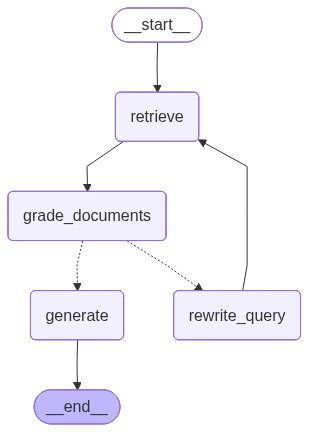

saved md: C:\Users\asguug\Documents\rag-agent\docs\week6_workflow_diagram.md
saved png: C:\Users\asguug\Documents\rag-agent\docs\week6_workflow_diagram.png


In [ ]:
from IPython.display import Image, display

# 저장 폴더
DIAGRAM_DIR = PROJECT_ROOT / "docs"
DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)

md_path = DIAGRAM_DIR / "week6_workflow_diagram.md"
png_path = DIAGRAM_DIR / "week6_workflow_diagram.png"

# 1) Mermaid 텍스트 생성
mermaid_text = agentic_rag_graph.get_graph().draw_mermaid()

# 2) Markdown 파일 저장
diagram_md = "\n".join([
    "# Week 6 Agentic RAG Workflow Diagram",
    "",
    "```mermaid",
    mermaid_text,
    "```",
    "",
])

md_path.write_text(diagram_md, encoding="utf-8")

# 3) PNG 이미지 생성 + 저장 + 노트북에 표시
png_bytes = agentic_rag_graph.get_graph().draw_mermaid_png()

png_path.write_bytes(png_bytes)

display(Image(png_bytes))

print("saved md:", md_path)
print("saved png:", png_path)